In [1]:
import numpy as np
import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader, random_split
from models.srno.model import EDSREncoder, SRONET
from models.srno import config
from datasets.super_res_dataset import SuperResDataset
from datasets.sr_tiny_dataset_srno import SRTinyDataset
from metrics.image_metrics import mseLoss, ssimLoss, psnrLoss, lpipsLoss, fsimLoss, epiLoss
from metrics.physical_metrics import LossTKE
from typing import Tuple

Setting up [LPIPS] perceptual loss: trunk [vgg], v[0.1], spatial [off]


c:\Users\vinic\OneDrive\Área de Trabalho\Mestrado\tese-vinicius\.venv\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\vinic\OneDrive\Área de Trabalho\Mestrado\tese-vinicius\.venv\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Loading model from: c:\Users\vinic\OneDrive\Área de Trabalho\Mestrado\tese-vinicius\.venv\Lib\site-packages\lpips\weights\v0.1\vgg.pth


In [13]:
# In your evaluation script
test_dataset = SRTinyDataset(
    hr_files=['data/100/window_2023.npy'],
    random_downsampling=False,
    downsample_factor=4
)

test_loader = DataLoader(
    test_dataset,
    batch_size=1,  # or smaller if memory is tight
    shuffle=False  # Don't shuffle test data
)

device = 'cuda' if torch.cuda.is_available() else 'cpu'

# Load checkpoint
checkpoint = torch.load('./models/srno/output/weights/SRONET_best.pth',
                       map_location=torch.device(device))

# Extract just the model state dict
encoder = EDSREncoder(n_resblocks=config.N_RESBLOCKS, n_feats=config.N_FEATS,
                        res_scale=config.RES_SCALE, n_colors=2)
model   = SRONET(encoder=encoder, width=config.WIDTH, blocks=config.BLOCKS, n_out=2)
model = model.to(device)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

SRONET(
  (encoder): EDSREncoder(
    (head): Conv2d(2, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (body): Sequential(
      (0): ResBlock(
        (body): Sequential(
          (0): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (1): ReLU(inplace=True)
          (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        )
      )
      (1): ResBlock(
        (body): Sequential(
          (0): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (1): ReLU(inplace=True)
          (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        )
      )
      (2): ResBlock(
        (body): Sequential(
          (0): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (1): ReLU(inplace=True)
          (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        )
      )
      (3): ResBlock(
        (body): Sequential(
          (0): Conv2d(64, 6

In [14]:
def evaluate_model(model, test_loader, device):
    model.eval()
    
    metrics = {
        'mse': {'u': [], 'v': []},
        'ssim': {'u': [], 'v': []},
        'psnr': {'u': [], 'v': []},
        'lpips': {'u': [], 'v': []},
        'fsim': {'u': [], 'v': []},
        'epi':{'u': [], 'v': []},
        'tke': {'u': [], 'v': []}
    }
    
    with torch.no_grad():
        for idx, sample in enumerate(test_loader):
            inp   = sample['inp'].to(device)
            hr    = sample['gt'].to(device)
            coord = sample['coord'].to(device)
            cell  = sample['cell'].to(device)
            output = model(inp, coord, cell)
            # Compute metrics for each channel
            for channel in range(2):  # u and v components
                channel_label = 'u' if channel == 0 else 'v'
                metrics['mse'][f'{channel_label}'].append(mseLoss(output, hr, channel, idx))
                metrics['ssim'][f'{channel_label}'].append(ssimLoss(output, hr, channel, idx))
                metrics['psnr'][f'{channel_label}'].append(psnrLoss(output, hr, channel, idx))
                metrics['lpips'][f'{channel_label}'].append(lpipsLoss(output, hr, channel, idx))
                metrics['fsim'][f'{channel_label}'].append(fsimLoss(output, hr, channel, idx))
                metrics['epi'][f'{channel_label}'].append(epiLoss(output, hr, channel, idx))
                metrics['tke'][f'{channel_label}'].append(LossTKE(output, hr, channel, idx))

    # Aggregate results
    results = {k: {'u': {'mean': np.mean(v['u']), 'std': np.std(v['u'])},
                    'v': {'mean': np.mean(v['v']), 'std': np.std(v['v'])}}
               for k, v in metrics.items()}
    return results

In [15]:
# results = evaluate_model(model, test_loader, device)
# print(results)

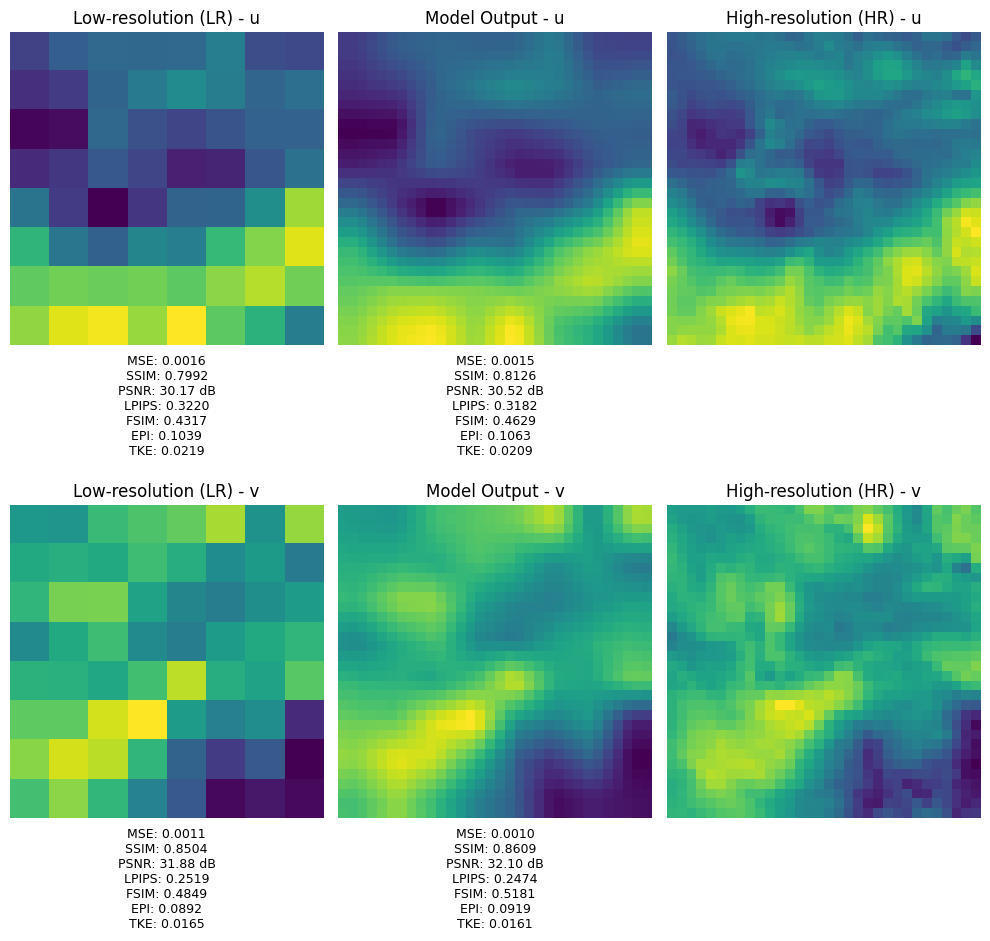

In [19]:
import matplotlib.pyplot as plt
import random

random_idx = random.randint(0, len(test_dataset) - 1)
sample = test_dataset[random_idx]
inp   = sample['inp'].unsqueeze(0).to(device)
coord = sample['coord'].unsqueeze(0).to(device)
cell  = sample['cell'].unsqueeze(0).to(device)
gt = torch.from_numpy(sample['gt']).unsqueeze(0).to(device)
lr, hr = inp, gt
output = model(inp, coord, cell)

fig, axes = plt.subplots(2, 3, figsize=(10, 10))

for channel in range(2):
    channel_label = 'u' if channel == 0 else 'v'
    axes[channel, 0].imshow(lr[0][channel].cpu().numpy())
    axes[channel, 0].set_title(f'Low-resolution (LR) - {channel_label}')
    axes[channel, 0].axis('off')

    axes[channel, 1].imshow(output[0][channel].detach().cpu().numpy())
    axes[channel, 1].set_title(f'Model Output - {channel_label}')
    axes[channel, 1].axis('off')

    axes[channel, 2].imshow(hr[0][channel].cpu().numpy())
    axes[channel, 2].set_title(f'High-resolution (HR) - {channel_label}')
    axes[channel, 2].axis('off')

    # Compute and display metrics for LR vs HR
    lr_up = F.interpolate(lr, size=hr.shape[-2:], mode='bilinear', align_corners=False)

    mse_value  = mseLoss(lr_up.detach(), hr.detach(), channel, 0)
    ssim_value = ssimLoss(lr_up.detach(), hr.detach(), channel, 0)
    psnr_value = psnrLoss(lr_up.detach(), hr.detach(), channel, 0)
    lpips_value = lpipsLoss(lr_up.detach(), hr.detach(), channel, 0)
    fsim_value = fsimLoss(lr_up.detach(), hr.detach(), channel, 0)
    epi_value = epiLoss(lr_up.detach(), hr.detach(), channel, 0)
    tke_value = LossTKE(lr_up.detach(), hr.detach(), channel, 0)
    
    axes[channel, 0].text(0.5, -0.35, 
                          f'MSE: {mse_value:.4f}\nSSIM: {ssim_value:.4f}\nPSNR: {psnr_value:.2f} dB\n'
                          f'LPIPS: {lpips_value:.4f}\nFSIM: {fsim_value:.4f}\nEPI: {epi_value:.4f}\nTKE: {tke_value:.4f}',
                          transform=axes[channel, 0].transAxes,
                          ha='center', fontsize=9)

    # Compute and display metrics for Output vs HR
    mse_value = mseLoss(output.detach(), hr.detach(), channel, 0)
    ssim_value = ssimLoss(output.detach(), hr.detach(), channel, 0)
    psnr_value = psnrLoss(output.detach(), hr.detach(), channel, 0)
    lpips_value = lpipsLoss(output.detach(), hr.detach(), channel, 0)
    fsim_value = fsimLoss(output.detach(), hr.detach(), channel, 0)
    epi_value = epiLoss(output.detach(), hr.detach(), channel, 0)
    tke_value = LossTKE(output.detach(), hr.detach(), channel, 0)
    
    axes[channel, 1].text(0.5, -0.35, 
                          f'MSE: {mse_value:.4f}\nSSIM: {ssim_value:.4f}\nPSNR: {psnr_value:.2f} dB\n'
                          f'LPIPS: {lpips_value:.4f}\nFSIM: {fsim_value:.4f}\nEPI: {epi_value:.4f}\nTKE: {tke_value:.4f}',
                          transform=axes[channel, 1].transAxes,
                          ha='center', fontsize=9)

plt.tight_layout()
plt.show()

In [17]:
inp.shape, coord.shape, cell.shape, gt.shape

(torch.Size([1, 2, 8, 8]),
 torch.Size([1, 32, 32, 2]),
 torch.Size([1, 2]),
 torch.Size([1, 2, 32, 32]))